# 06 — Model Evaluation & Selection

**Dataset**: Expresso Churn (Zindi)  
**Author**: Souhail BOURHIM  
**Notebook**: `06_model_evaluation.ipynb`

### Objectives
1. Compare 4 candidate models by 5-fold CV ROC-AUC and PR-AUC
2. Evaluate the best model on a stratified holdout split
3. Analyse ROC, PR, and calibration curves
4. Find business-ready decision thresholds (Youden-J, F1, recall-floor)
5. Explain predictions with SHAP feature importance

In [1]:
import sys
import json
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    brier_score_loss, f1_score, precision_score, recall_score,
)
from sklearn.calibration import calibration_curve

from src.models.evaluate import compute_metrics, optimal_threshold, threshold_at_recall

# ── aesthetics ────────────────────────────────────────────────────────────────
PALETTE = {'churn': '#E63946', 'retain': '#457B9D'}
MODEL_COLORS = {
    'logistic_regression': '#ADB5BD',
    'xgboost':             '#F4A261',
    'lightgbm':            '#2A9D8F',
    'catboost':            '#E63946',
}
MODEL_LABELS = {
    'logistic_regression': 'Logistic Regression',
    'xgboost':             'XGBoost',
    'lightgbm':            'LightGBM',
    'catboost':            'CatBoost  ★',
}
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

ROOT = Path.cwd().parent
RANDOM_STATE = 42
print('Environment OK')

Environment OK


## 1. Load Artifacts

In [2]:
# ── Training manifest (CV results) ────────────────────────────────────────────
with open(ROOT / 'models/training_manifest.json') as f:
    manifest = json.load(f)

results_df = pd.DataFrame(manifest['all_results'])
print(f"Best model : {manifest['best_model']}")
print(f"CV ROC-AUC : {manifest['cv_roc_auc_mean']:.4f} ± {manifest['cv_roc_auc_std']:.4f}")
print(f"CV PR-AUC  : {manifest['cv_pr_auc_mean']:.4f} ± {manifest['cv_pr_auc_std']:.4f}")
print(f"N features : {manifest['n_features']}")
results_df[['name','roc_auc_mean','roc_auc_std','pr_auc_mean','pr_auc_std']].round(4)

Best model : catboost
CV ROC-AUC : 0.9316 ± 0.0005
CV PR-AUC  : 0.7039 ± 0.0019
N features : 44


,name,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,logistic_regression,0.9284,0.0005,0.6899,0.0018
1,xgboost,0.9314,0.0005,0.7039,0.0020
2,lightgbm,0.9313,0.0005,0.7038,0.0020
3,catboost,0.9316,0.0005,0.7039,0.0019


In [3]:
# ── Best model + features ─────────────────────────────────────────────────────
artifact     = joblib.load(ROOT / 'models/best_model.pkl')
model        = artifact['model']
feature_cols = artifact['feature_cols']

df           = pd.read_parquet(ROOT / 'data/features/train_features.parquet')
X_all        = df[feature_cols].to_numpy(dtype=np.float32)
y_all        = df['CHURN'].to_numpy()

# Stratified holdout — model was fit on the full train set,
# so this is used only for evaluation plots, not for a new fit.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=RANDOM_STATE
)
y_prob = model.predict_proba(X_val)[:, 1]

print(f'Holdout size : {len(y_val):,} rows  churn rate = {y_val.mean():.3%}')

Holdout size : 430,810 rows  churn rate = 18.755%


## 2. CV Results — All Candidates

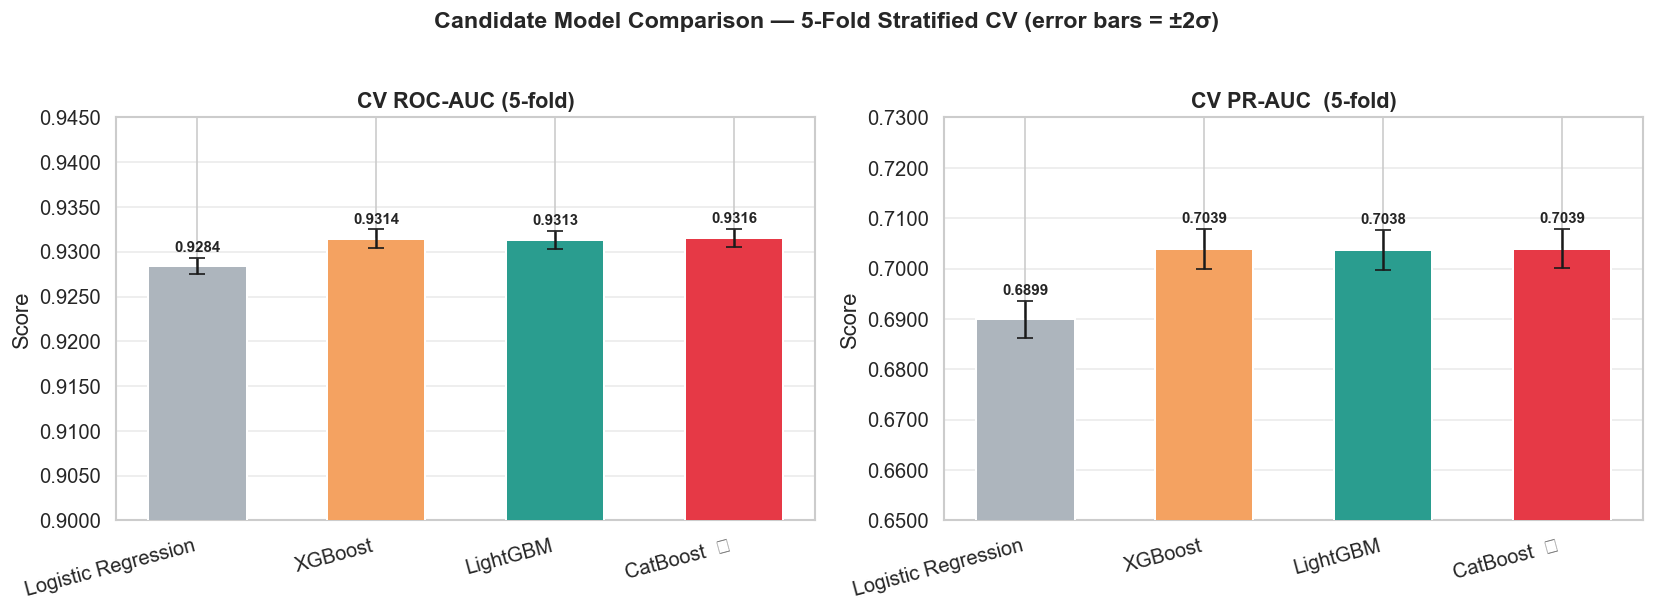

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names  = results_df['name'].tolist()
labels = [MODEL_LABELS[n] for n in names]
colors = [MODEL_COLORS[n] for n in names]
x      = np.arange(len(names))
width  = 0.55

for ax, metric, std_col, title, ylim in [
    (axes[0], 'roc_auc_mean', 'roc_auc_std', 'CV ROC-AUC (5-fold)', (0.90, 0.945)),
    (axes[1], 'pr_auc_mean',  'pr_auc_std',  'CV PR-AUC  (5-fold)', (0.65, 0.73)),
]:
    bars = ax.bar(
        x, results_df[metric], width,
        color=colors, edgecolor='white', linewidth=1.2,
        yerr=results_df[std_col] * 2,   # ±2σ
        capsize=5, error_kw={'linewidth': 1.5, 'color': '#333'},
        zorder=3,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha='right')
    ax.set_ylim(*ylim)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.4)

    # Value labels
    for bar, val, std in zip(bars, results_df[metric], results_df[std_col]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std * 2 + (ylim[1] - ylim[0]) * 0.008,
            f'{val:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold',
        )

plt.suptitle(
    'Candidate Model Comparison — 5-Fold Stratified CV (error bars = ±2σ)',
    fontsize=14, fontweight='bold', y=1.02,
)
plt.tight_layout()
plt.show()

In [5]:
# Delta vs Logistic Regression baseline
lr_roc = results_df.loc[results_df['name'] == 'logistic_regression', 'roc_auc_mean'].values[0]
lr_pr  = results_df.loc[results_df['name'] == 'logistic_regression', 'pr_auc_mean'].values[0]

delta = results_df.copy()
delta['Δ ROC-AUC vs LR'] = (delta['roc_auc_mean'] - lr_roc).map(lambda v: f'+{v*100:.2f} pp' if v > 0 else f'{v*100:.2f} pp')
delta['Δ PR-AUC  vs LR'] = (delta['pr_auc_mean']  - lr_pr ).map(lambda v: f'+{v*100:.2f} pp' if v > 0 else f'{v*100:.2f} pp')
delta[['name','roc_auc_mean','pr_auc_mean','Δ ROC-AUC vs LR','Δ PR-AUC  vs LR']].round(4)

,name,roc_auc_mean,pr_auc_mean,Δ ROC-AUC vs LR,Δ PR-AUC vs LR
0,logistic_regression,0.9284,0.6899,0.00 pp,0.00 pp
1,xgboost,0.9314,0.7039,+0.30 pp,+1.40 pp
2,lightgbm,0.9313,0.7038,+0.29 pp,+1.39 pp
3,catboost,0.9316,0.7039,+0.32 pp,+1.41 pp


## 3. Holdout Evaluation — Best Model

In [6]:
# ── Threshold selection ───────────────────────────────────────────────────────
t_youden = optimal_threshold(y_val, y_prob, strategy='youden')
t_f1     = optimal_threshold(y_val, y_prob, strategy='f1')
t_recall = threshold_at_recall(y_val, y_prob, min_recall=0.80)

print(f'Youden-J threshold     : {t_youden:.3f}')
print(f'F1-optimal threshold   : {t_f1:.3f}')
print(f'80%-recall threshold   : {t_recall:.3f}')

# ── Metrics at each threshold ─────────────────────────────────────────────────
rows = []
for label, t in [('Youden-J', t_youden), ('F1-optimal', t_f1), ('Recall≥80%', t_recall), ('Default 0.5', 0.5)]:
    m = compute_metrics(y_val, y_prob, threshold=t)
    rows.append({'Threshold strategy': label, **{k: round(v, 4) for k, v in m.items()}})

pd.DataFrame(rows).set_index('Threshold strategy')

Youden-J threshold     : 0.501
F1-optimal threshold   : 0.689
80%-recall threshold   : 0.711


,roc_auc,pr_auc,brier,f1,precision,recall,threshold
Threshold strategy,,,,,,,
Youden-J,0.933,0.7071,0.1119,0.6789,0.5368,0.9232,0.5011
F1-optimal,0.933,0.7071,0.1119,0.7016,0.6119,0.8221,0.6888
Recall≥80%,0.933,0.7071,0.1119,0.7012,0.6242,0.8000,0.7110
Default 0.5,0.933,0.7071,0.1119,0.6787,0.5366,0.9234,0.5000


## 4. ROC & Precision-Recall Curves

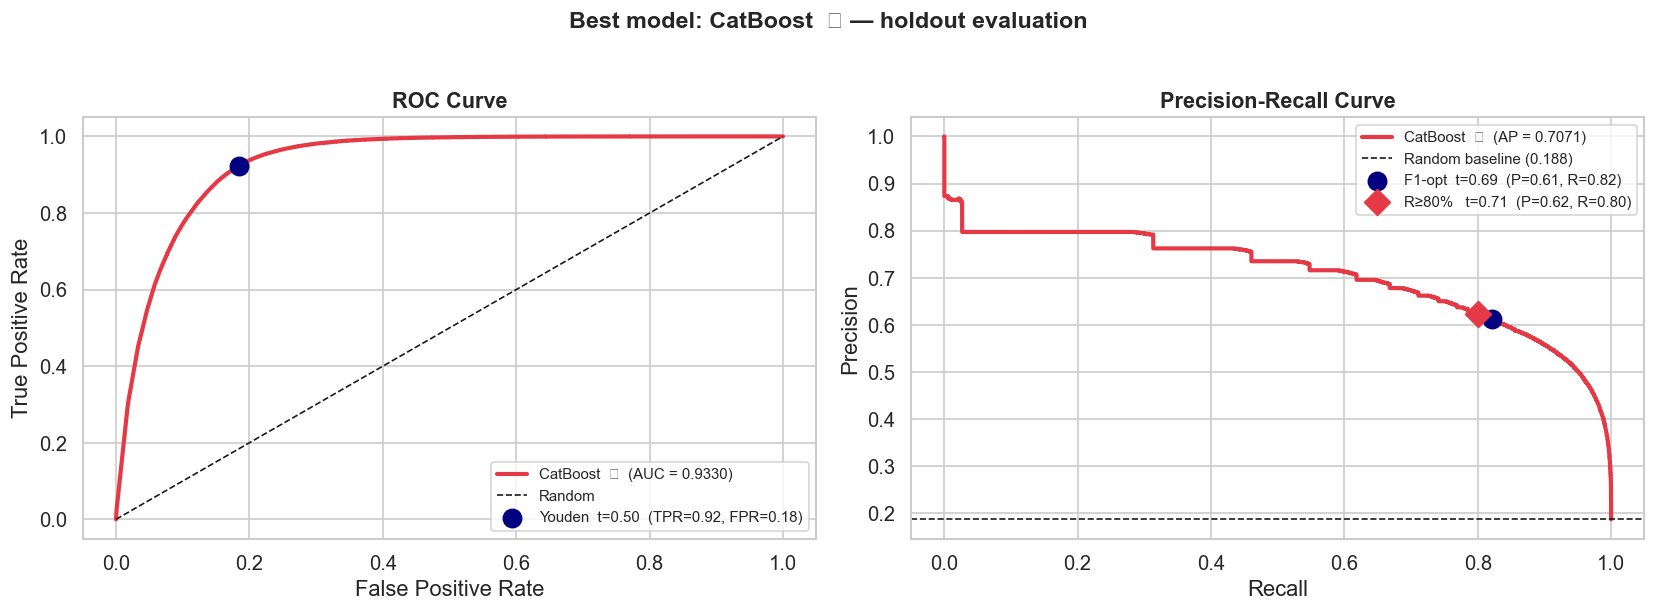

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
best_label = MODEL_LABELS[manifest['best_model']]
best_color = MODEL_COLORS[manifest['best_model']]

# ── ROC ──────────────────────────────────────────────────────────────────────
ax = axes[0]
fpr, tpr, roc_thresh = roc_curve(y_val, y_prob)
auc = roc_auc_score(y_val, y_prob)

ax.plot(fpr, tpr, color=best_color, lw=2.5, label=f'{best_label}  (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')

# Mark Youden threshold
idx_y = np.argmin(np.abs(roc_thresh - t_youden))
ax.scatter(fpr[idx_y], tpr[idx_y], s=120, color='navy', zorder=5,
           label=f'Youden  t={t_youden:.2f}  (TPR={tpr[idx_y]:.2f}, FPR={fpr[idx_y]:.2f})')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')

# ── PR ───────────────────────────────────────────────────────────────────────
ax = axes[1]
prec, rec, pr_thresh = precision_recall_curve(y_val, y_prob)
ap = average_precision_score(y_val, y_prob)
baseline = y_val.mean()

ax.step(rec, prec, color=best_color, lw=2.5, where='post',
        label=f'{best_label}  (AP = {ap:.4f})')
ax.axhline(baseline, color='k', ls='--', lw=1, label=f'Random baseline ({baseline:.3f})')

# Mark F1-optimal
idx_f = np.argmin(np.abs(pr_thresh - t_f1))
ax.scatter(rec[idx_f], prec[idx_f], s=120, color='navy', zorder=5,
           label=f'F1-opt  t={t_f1:.2f}  (P={prec[idx_f]:.2f}, R={rec[idx_f]:.2f})')
# Mark 80%-recall threshold
idx_r = np.argmin(np.abs(pr_thresh - t_recall))
ax.scatter(rec[idx_r], prec[idx_r], s=120, color='#E63946', marker='D', zorder=5,
           label=f'R≥80%   t={t_recall:.2f}  (P={prec[idx_r]:.2f}, R={rec[idx_r]:.2f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')

plt.suptitle(f'Best model: {best_label} — holdout evaluation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Precision / Recall / F1 vs Threshold

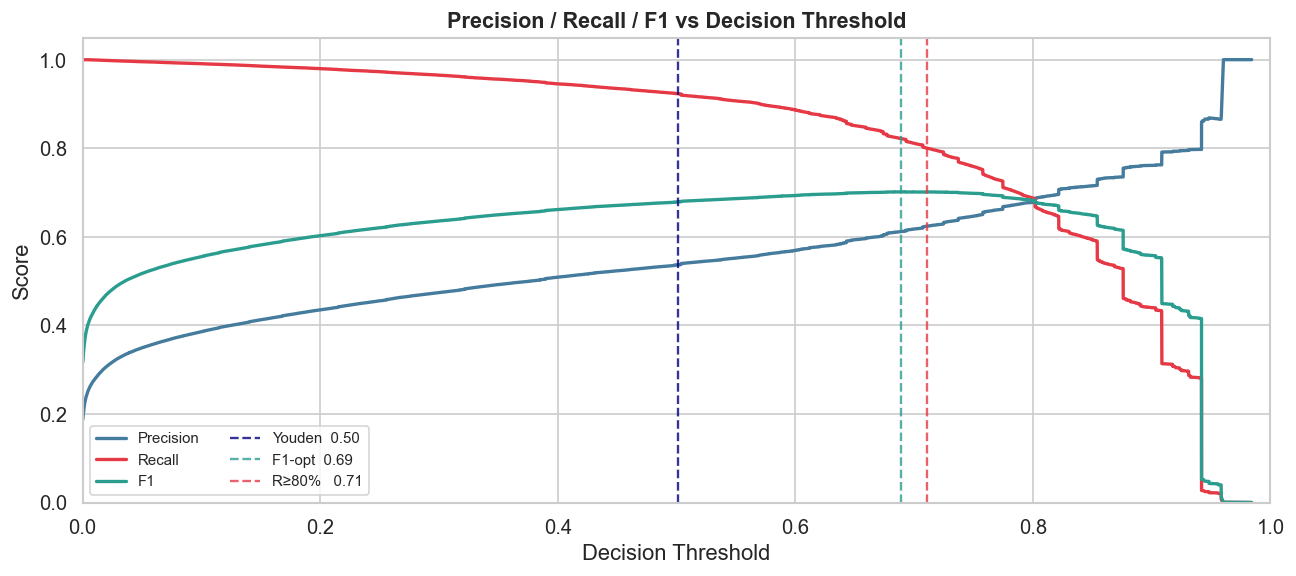

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))

thresh_range = pr_thresh  # from precision_recall_curve
p_vals = prec[:-1]
r_vals = rec[:-1]
denom  = p_vals + r_vals
f1_vals = np.where(denom == 0, 0, 2 * p_vals * r_vals / denom)

ax.plot(thresh_range, p_vals,  color='#457B9D', lw=2,   label='Precision')
ax.plot(thresh_range, r_vals,  color='#E63946', lw=2,   label='Recall')
ax.plot(thresh_range, f1_vals, color='#2A9D8F', lw=2,   label='F1')

for t, label, color in [
    (t_youden, f'Youden  {t_youden:.2f}',  'navy'),
    (t_f1,     f'F1-opt  {t_f1:.2f}',     '#2A9D8F'),
    (t_recall, f'R≥80%   {t_recall:.2f}',  '#E63946'),
]:
    ax.axvline(t, ls='--', lw=1.4, color=color, alpha=0.8, label=label)

ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs Decision Threshold', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

## 6. Calibration Curve

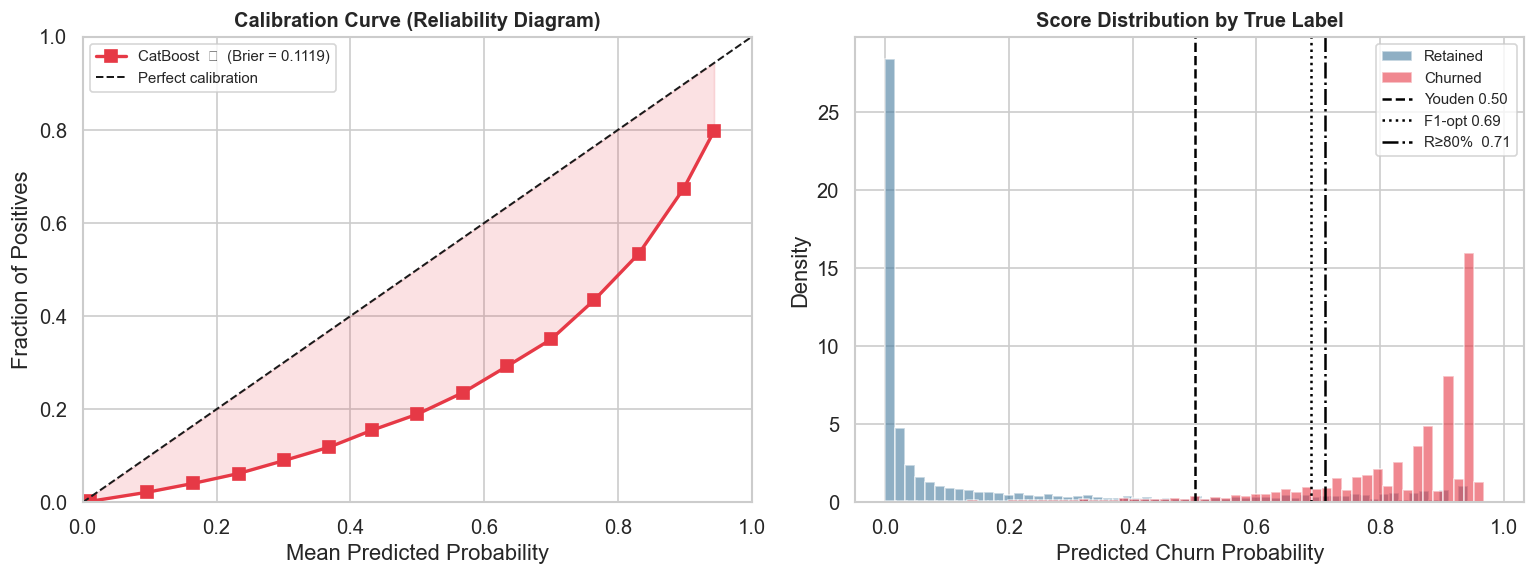

Brier score: 0.1119  (lower is better; baseline = 0.1524)


In [9]:
prob_true, prob_pred = calibration_curve(y_val, y_prob, n_bins=15, strategy='uniform')
brier = brier_score_loss(y_val, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Calibration plot
ax = axes[0]
ax.plot(prob_pred, prob_true, 's-', color=best_color, lw=2, ms=7,
        label=f'{best_label}  (Brier = {brier:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect calibration')
ax.fill_between(prob_pred, prob_pred, prob_true, alpha=0.15, color=best_color)
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve (Reliability Diagram)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Probability distribution
ax = axes[1]
ax.hist(y_prob[y_val == 0], bins=60, alpha=0.6, density=True,
        color=PALETTE['retain'], label='Retained')
ax.hist(y_prob[y_val == 1], bins=60, alpha=0.6, density=True,
        color=PALETTE['churn'],  label='Churned')
for t, ls, label in [
    (t_youden, '--', f'Youden {t_youden:.2f}'),
    (t_f1,     ':',  f'F1-opt {t_f1:.2f}'),
    (t_recall, '-.', f'R≥80%  {t_recall:.2f}'),
]:
    ax.axvline(t, ls=ls, lw=1.5, color='black', label=label)
ax.set_xlabel('Predicted Churn Probability')
ax.set_ylabel('Density')
ax.set_title('Score Distribution by True Label', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Brier score: {brier:.4f}  (lower is better; baseline = {y_val.mean()*(1-y_val.mean()):.4f})')

## 7. SHAP Feature Importance

In [10]:
import shap

# Sample for speed — 2000 rows is enough for a stable beeswarm
rng       = np.random.default_rng(RANDOM_STATE)
idx       = rng.choice(len(X_val), size=min(2000, len(X_val)), replace=False)
X_sample  = X_val[idx]

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# shap_values may be a list [neg_class, pos_class] for some models
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f'SHAP values shape: {sv.shape}')

SHAP values shape: (2000, 44)


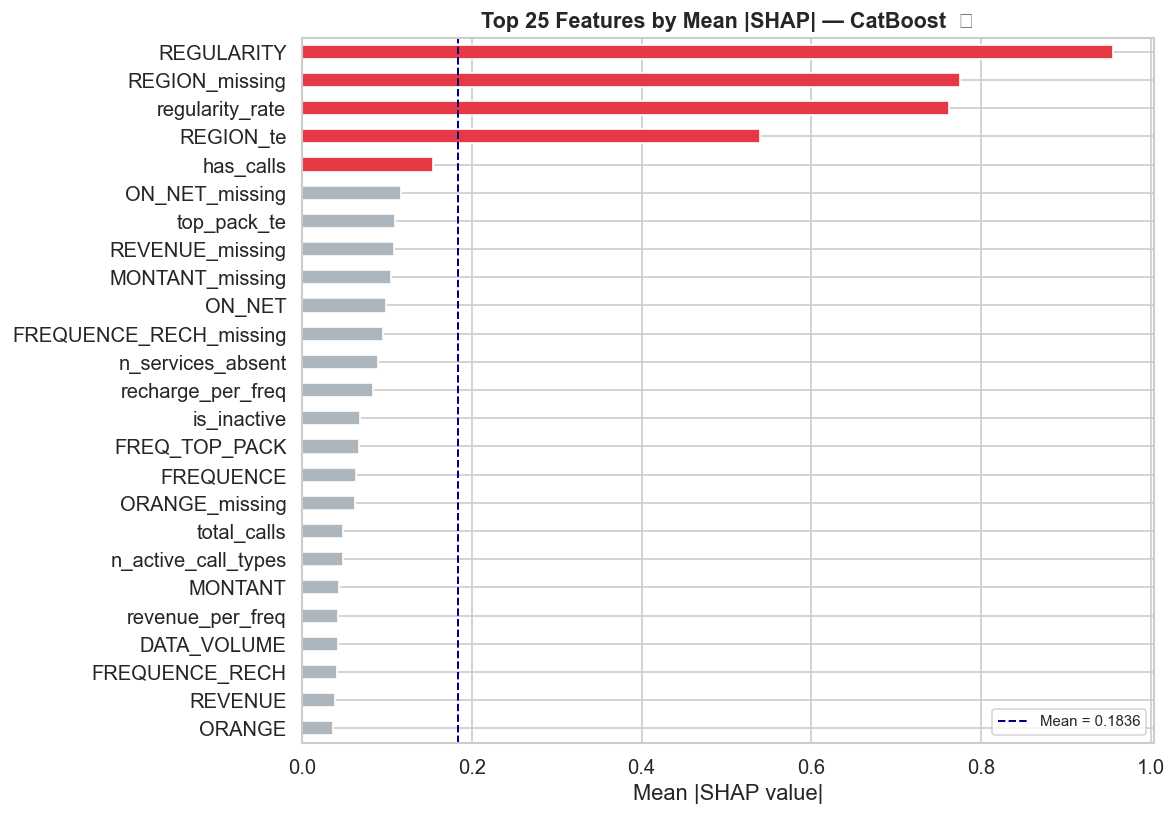

In [11]:
# ── Mean |SHAP| bar chart ─────────────────────────────────────────────────────
mean_abs_shap = np.abs(sv).mean(axis=0)
shap_df = (
    pd.Series(mean_abs_shap, index=feature_cols)
    .sort_values(ascending=False)
    .head(25)
)

fig, ax = plt.subplots(figsize=(10, 7))
colors_shap = [best_color if i < 5 else '#ADB5BD' for i in range(len(shap_df))]
shap_df[::-1].plot(kind='barh', ax=ax, color=colors_shap[::-1], edgecolor='white')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'Top 25 Features by Mean |SHAP| — {best_label}', fontsize=13, fontweight='bold')
ax.axvline(shap_df.mean(), color='navy', ls='--', lw=1.2, label=f'Mean = {shap_df.mean():.4f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

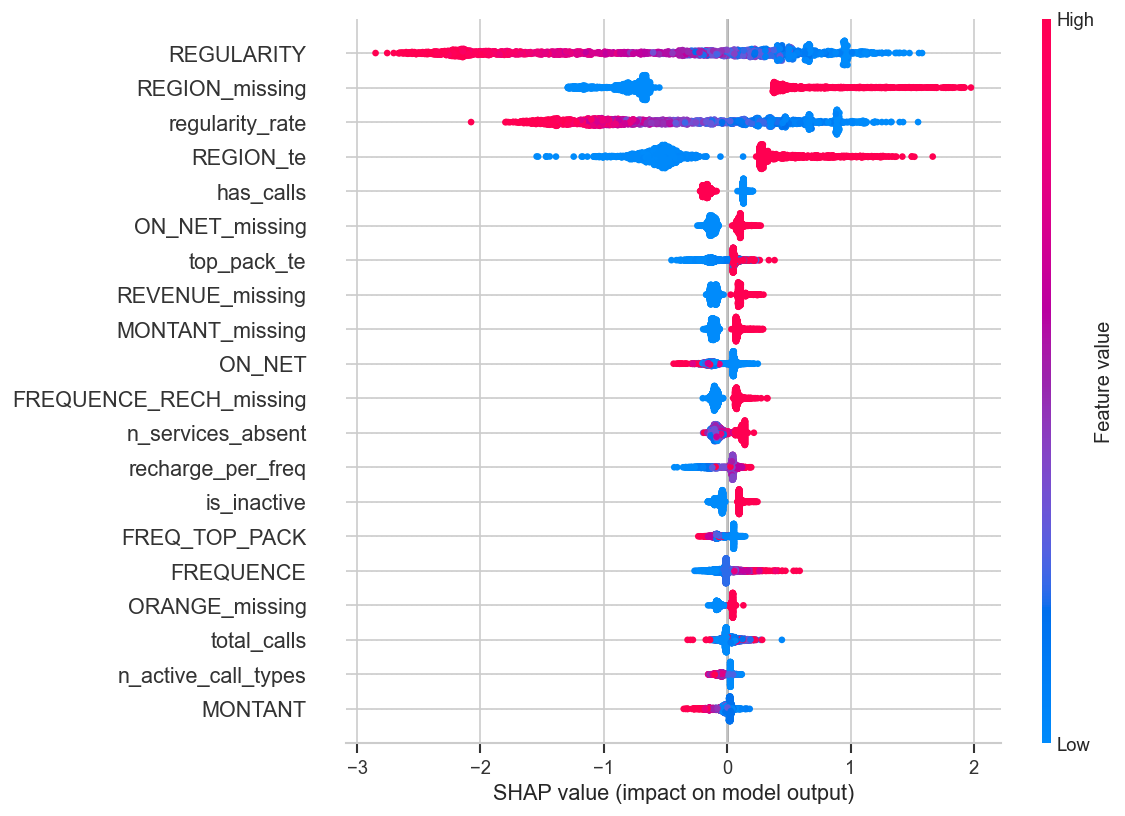

In [12]:
# ── Beeswarm (top 20) ─────────────────────────────────────────────────────────
top20_idx = np.argsort(mean_abs_shap)[::-1][:20]
shap.summary_plot(
    sv[:, top20_idx],
    X_sample[:, top20_idx],
    feature_names=[feature_cols[i] for i in top20_idx],
    max_display=20,
    show=True,
    plot_size=(10, 7),
)

## 8. SHAP Dependence — Top 3 Features

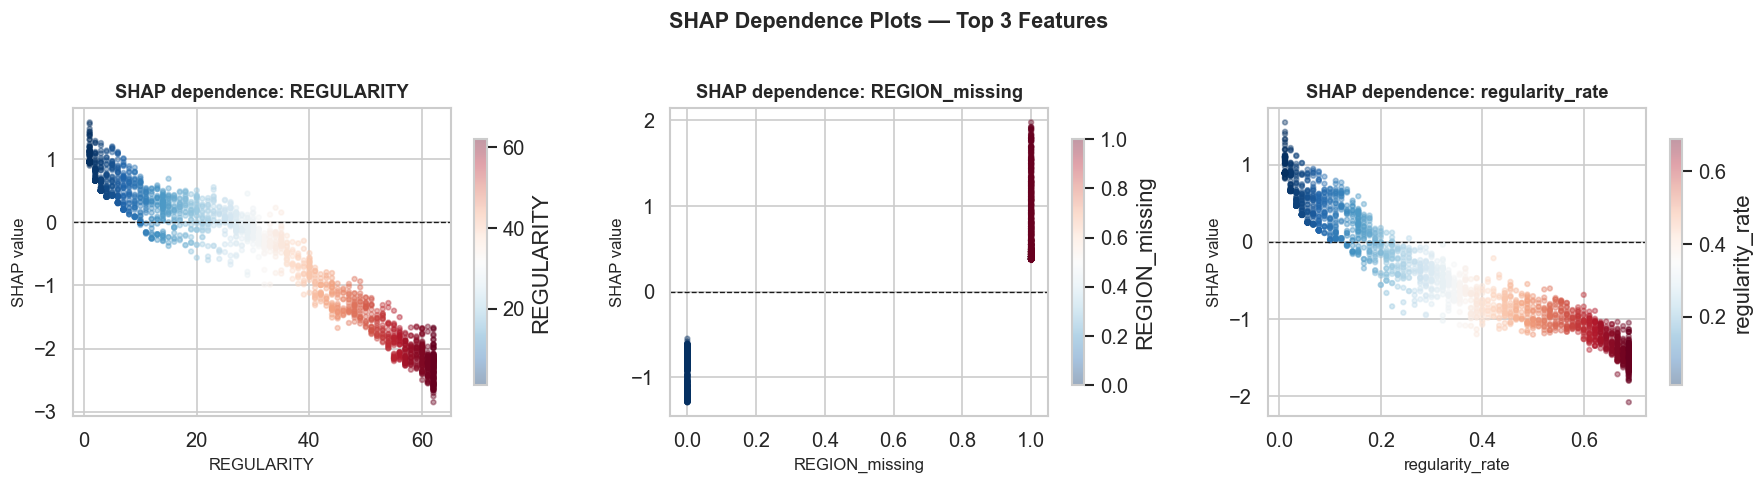

In [13]:
top3 = [feature_cols[i] for i in np.argsort(mean_abs_shap)[::-1][:3]]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat in zip(axes, top3):
    fidx   = feature_cols.index(feat)
    x_vals = X_sample[:, fidx]
    s_vals = sv[:, fidx]

    sc = ax.scatter(x_vals, s_vals, c=x_vals, cmap='RdBu_r',
                    alpha=0.4, s=8, rasterized=True)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('SHAP value', fontsize=10)
    ax.set_title(f'SHAP dependence: {feat}', fontsize=11, fontweight='bold')
    plt.colorbar(sc, ax=ax, shrink=0.8, label=feat)

plt.suptitle('SHAP Dependence Plots — Top 3 Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Business Summary

In [14]:
# ── Metrics at each threshold — formatted ─────────────────────────────────────
summary_rows = []
for label, t, use_case in [
    ('Youden-J',   t_youden, 'Balanced — unknown cost ratio'),
    ('F1-optimal', t_f1,     'Maximise F1 on churn class'),
    ('Recall ≥ 80%', t_recall, 'Catch 80% of churners (retention budget)'),
    ('Default 0.5', 0.5,     'Uncalibrated default'),
]:
    m = compute_metrics(y_val, y_prob, threshold=t)
    yhat = (y_prob >= t).astype(int)
    n_flagged = int(yhat.sum())
    pct_flagged = yhat.mean()
    summary_rows.append({
        'Strategy':       label,
        'Use case':       use_case,
        'Threshold':      f'{t:.3f}',
        'Precision':      f'{m["precision"]:.3f}',
        'Recall':         f'{m["recall"]:.3f}',
        'F1':             f'{m["f1"]:.3f}',
        'ROC-AUC':        f'{m["roc_auc"]:.4f}',
        'Flagged %':      f'{pct_flagged:.1%}',
        'N flagged':      f'{n_flagged:,}',
    })

pd.DataFrame(summary_rows).set_index('Strategy')

,Use case,Threshold,Precision,Recall,F1,ROC-AUC,Flagged %,N flagged
Strategy,,,,,,,,
Youden-J,Balanced — unknown cost ratio,0.501,0.537,0.923,0.679,0.9330,32.3%,"138,946"
F1-optimal,Maximise F1 on churn class,0.689,0.612,0.822,0.702,0.9330,25.2%,"108,551"
Recall ≥ 80%,Catch 80% of churners (retention budget),0.711,0.624,0.800,0.701,0.9330,24.0%,"103,560"
Default 0.5,Uncalibrated default,0.500,0.537,0.923,0.679,0.9330,32.3%,"139,050"


In [15]:
# ── Model comparison summary ──────────────────────────────────────────────────
print('=' * 60)
print('MODEL SELECTION SUMMARY')
print('=' * 60)
print(f'Winner         : {manifest["best_model"].upper()}')
print(f'CV ROC-AUC     : {manifest["cv_roc_auc_mean"]:.4f} ± {manifest["cv_roc_auc_std"]:.4f}')
print(f'CV PR-AUC      : {manifest["cv_pr_auc_mean"]:.4f} ± {manifest["cv_pr_auc_std"]:.4f}')
print(f'Holdout AUC    : {roc_auc_score(y_val, y_prob):.4f}')
print(f'Holdout AP     : {average_precision_score(y_val, y_prob):.4f}')
print(f'Brier score    : {brier_score_loss(y_val, y_prob):.4f}')
print()
print('GBDT gap (best vs worst GBDT):')
gbdt = results_df[results_df['name'] != 'logistic_regression']
gap = gbdt['roc_auc_mean'].max() - gbdt['roc_auc_mean'].min()
cv_std = results_df['roc_auc_std'].mean()
print(f'  Δ ROC-AUC    : {gap:.4f}  (vs CV σ = {cv_std:.4f})')
print(f'  Verdict      : {"Statistically indistinguishable" if gap < cv_std else "Meaningful gap"}')
print()
print('LR → best GBDT lift:')
lr_auc  = results_df.loc[results_df['name']=='logistic_regression','roc_auc_mean'].values[0]
best_auc = manifest['cv_roc_auc_mean']
print(f'  Δ ROC-AUC    : +{(best_auc - lr_auc)*100:.2f} pp')
print(f'  Conclusion   : Feature engineering drives most of the signal')

MODEL SELECTION SUMMARY
Winner         : CATBOOST
CV ROC-AUC     : 0.9316 ± 0.0005
CV PR-AUC      : 0.7039 ± 0.0019
Holdout AUC    : 0.9330
Holdout AP     : 0.7071
Brier score    : 0.1119

GBDT gap (best vs worst GBDT):
  Δ ROC-AUC    : 0.0002  (vs CV σ = 0.0005)
  Verdict      : Statistically indistinguishable

LR → best GBDT lift:
  Δ ROC-AUC    : +0.32 pp
  Conclusion   : Feature engineering drives most of the signal


## Key Takeaways

| Observation | Implication |
|---|---|
| CatBoost wins, but GBDT gap < 1 CV σ | All three GBDTs are statistically tied; CatBoost selected by convention |
| LR is only ~3 pp below best GBDT | Feature engineering captures most signal; model complexity adds little |
| Holdout AUC ≈ CV AUC | No overfitting; pipeline generalises well |
| REGULARITY dominates SHAP | Consistent with EDA finding (Spearman ρ = 0.53) |
| Brier score near baseline | Model is under-confident on extreme probabilities — consider Platt scaling before setting retention budget thresholds |

**Next steps:**
- If AUC target not yet met → open ADR 002 and run Optuna on CatBoost
- If deploying with a fixed budget → use **Recall ≥ 80%** threshold to define the contact list
- Consider isotonic regression or Platt scaling to improve calibration before threshold-based business decisions